# 01 Heuristics

Static and dynamic DVRPTW examples with visualisations.

In [1]:
import sys, os
print(sys.executable)
print(os.getcwd())

/Users/giuseppe/Documents/personal/fyp-vrp/fyp-vrp-venv/bin/python
/Users/giuseppe/Documents/personal/fyp-vrp/final_solution/dvrptw-benchmark/notebooks


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.heuristics.gls import GLSSolver
from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.viz.timeline_plot import plot_timeline
from dvrptw_bench.viz.convergence_plot import plot_convergence
from dvrptw_bench.viz.inspector import inspect_dynamic, inspect_static 

import logging
import sys

gls_logger = logging.getLogger("dvrptw_bench.heuristics.gls")
gls_logger.handlers.clear()
out = Path('../outputs/notebook_heuristics')

handler = logging.StreamHandler(sys.stdout)  # send to notebook cell output
handler.setLevel(logging.DEBUG)
handler.setFormatter(logging.Formatter("%(asctime)s| %(levelname)s | %(message)s"))

gls_logger.addHandler(handler)
gls_logger.setLevel(logging.DEBUG)
gls_logger.propagate = False

In [4]:
dataset_root = Path('../dataset')
instances = find_rc_instances(dataset_root)
assert instances, 'Place RC*.txt files under ../dataset/solomon_rc100/'
instance = parse_solomon(instances[0], max_customers=10)
instance.instance_id, instance.n_customers

('RC201.txt', 10)

## Static solve + visualisations

In [14]:

instance= parse_solomon(instances[0])
sol= ORToolsVRPTWSolver().solve(instance, time_limit_s=10)
gls = GLSSolver(debug=True,log_every=100).solve(instance, time_limit_s=300)
sol.total_distance, gls.total_distance

2026-03-01 17:03:42,911| DEBUG | GLS start: dist=2753.821 feasible=True score=2753.821
2026-03-01 17:03:42,939| DEBUG | iter=100 op=cross_exchange cand_dist=2857.030 cand_score=221090.655 feasible=False cap_v=0.000 tw_v=218.231 unserved=0
2026-03-01 17:03:42,967| DEBUG | iter=200 op=cross_exchange cand_dist=2739.510 cand_score=4144809.130 feasible=False cap_v=0.000 tw_v=4142.066 unserved=0
2026-03-01 17:03:42,994| DEBUG | iter=300 op=cross_exchange cand_dist=2846.625 cand_score=1139415.468 feasible=False cap_v=0.000 tw_v=1136.564 unserved=0
2026-03-01 17:03:43,022| DEBUG | iter=400 op=cross_exchange cand_dist=2700.088 cand_score=235221.580 feasible=False cap_v=0.000 tw_v=232.515 unserved=0
2026-03-01 17:03:43,050| DEBUG | iter=500 op=cross_exchange cand_dist=2844.604 cand_score=1352048.233 feasible=False cap_v=0.000 tw_v=1349.197 unserved=0
2026-03-01 17:03:43,078| DEBUG | iter=600 op=cross_exchange cand_dist=2785.315 cand_score=5389536.243 feasible=False cap_v=0.000 tw_v=5386.743 unse

(1264.716299832331, 2084.1329695591644)

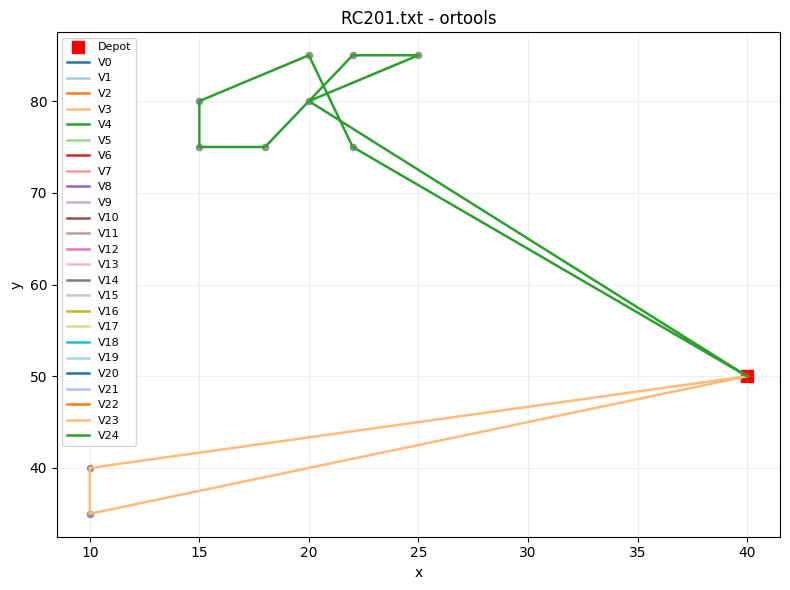

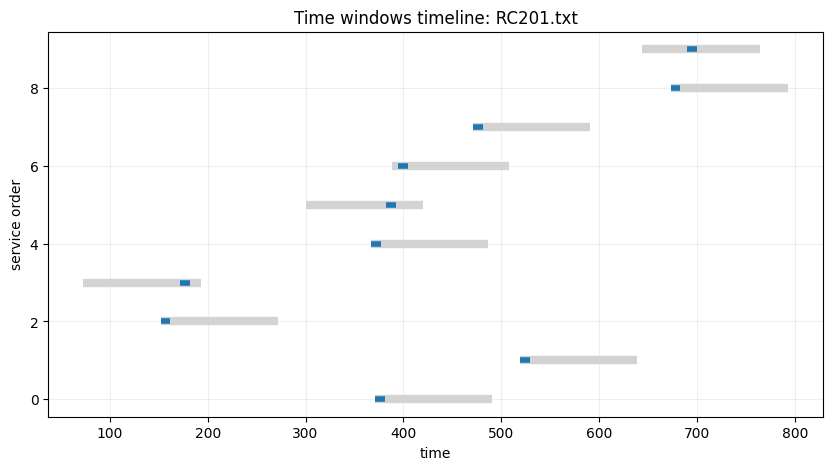

In [ ]:
# plot_scenario(instance)
plot_routes(instance, sol)
plot_timeline(instance, sol)

## Dynamic simulation example

In [15]:
sim = DynamicSimulator(instance)

dyn_sol, events, scenario = sim.run(
    lambda snap_inst, budget: ORToolsVRPTWSolver().solve(snap_inst, budget),
    epsilon=0.4,
    budget_s=1,
    seed=1,
    cutoff_ratio=0.1
    
)
len(events), None if dyn_sol is None else dyn_sol.total_distance
dyn_sol

Dynamic scenario with 10 dynamic customers (epsilon=0.10), cutoff at 96.0s (10.00% of horizon)
Dynamic customer IDs: [4, 14, 25, 32, 44, 48, 71, 80, 90, 93]


Solution(strategy='ortools:executed', routes=[Route(vehicle_id=0, node_ids=[65, 59, 14, 47, 15, 11, 12, 75, 16, 73, 86, 87, 78, 10, 97, 74, 13, 17, 58]), Route(vehicle_id=1, node_ids=[92, 63, 33, 30, 29, 76, 85, 50, 34, 32, 26, 89]), Route(vehicle_id=2, node_ids=[72, 36, 39, 42, 44, 71, 41, 40, 43, 35]), Route(vehicle_id=3, node_ids=[45, 5, 2, 6, 7, 79, 8, 46, 3, 1, 60, 4]), Route(vehicle_id=4, node_ids=[83, 52, 64, 23, 21, 19, 99, 18, 22, 57, 49, 20, 66, 24, 48, 77, 25]), Route(vehicle_id=5, node_ids=[61, 81, 54, 96, 68, 100, 70]), Route(vehicle_id=6, node_ids=[95, 62, 67, 94, 84, 56, 91, 93]), Route(vehicle_id=7, node_ids=[82, 98, 53, 90]), Route(vehicle_id=8, node_ids=[69, 88, 55]), Route(vehicle_id=9, node_ids=[80])], total_distance=1779.124162440741, feasible=False, violations={'unserved': 7.0, 'late_count': 7.0, 'late_sum': 41.50787527873115, 'capacity': 0.0}, solve_time_s=0.0, details={'served_count': 93})

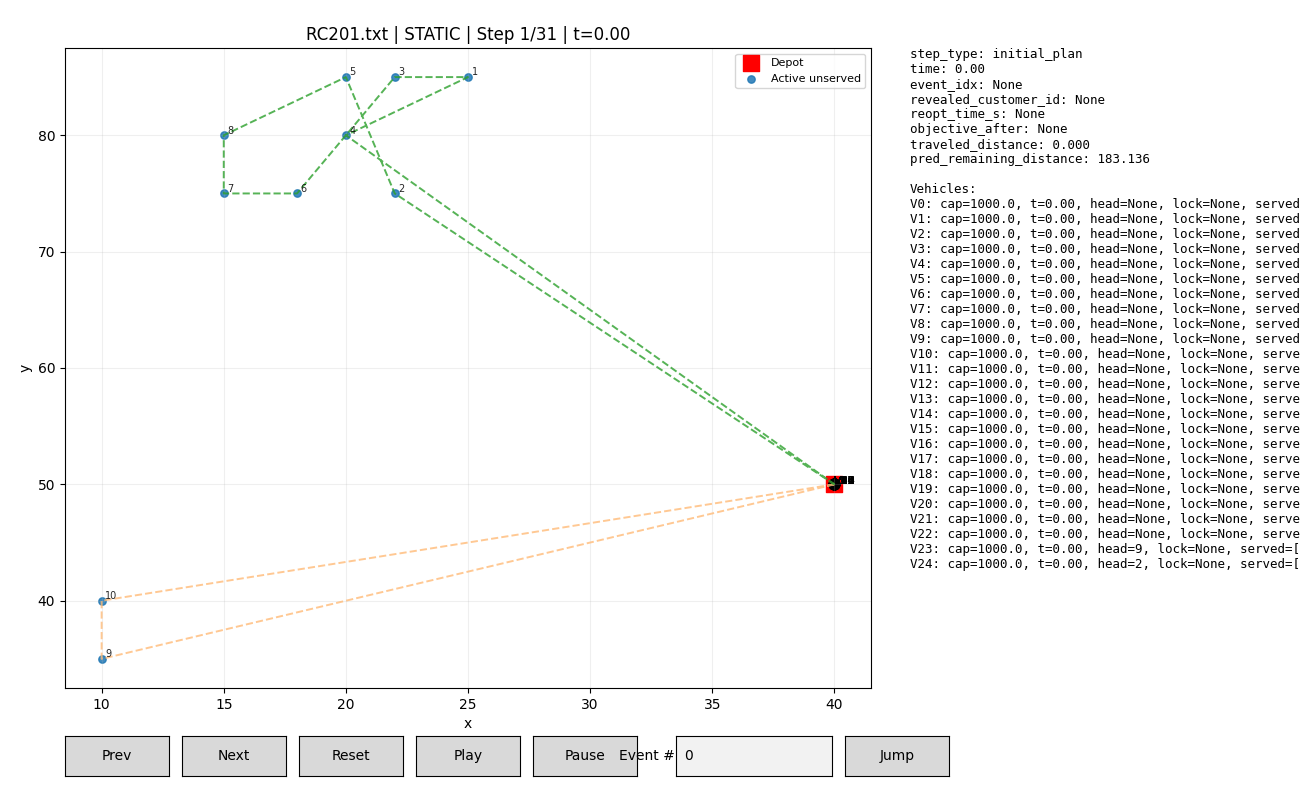

In [10]:
%matplotlib widget

inspect_static(instance, sol)

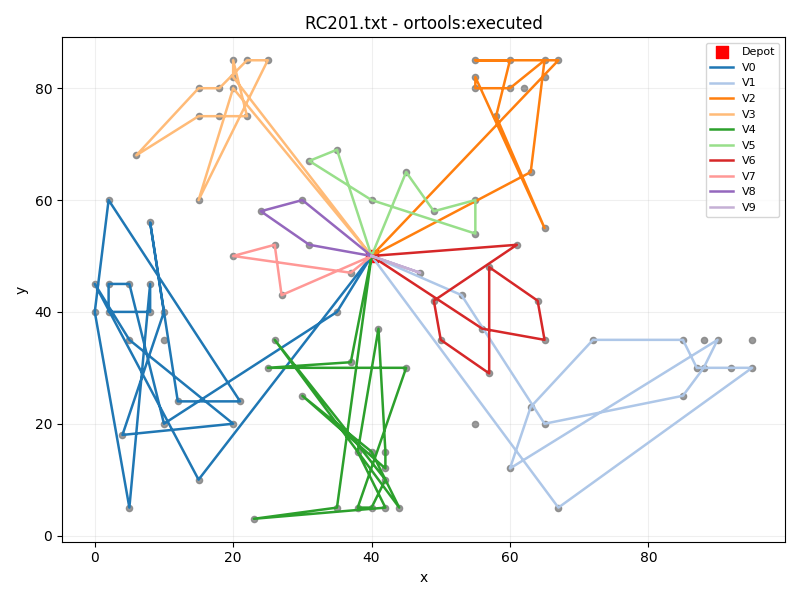

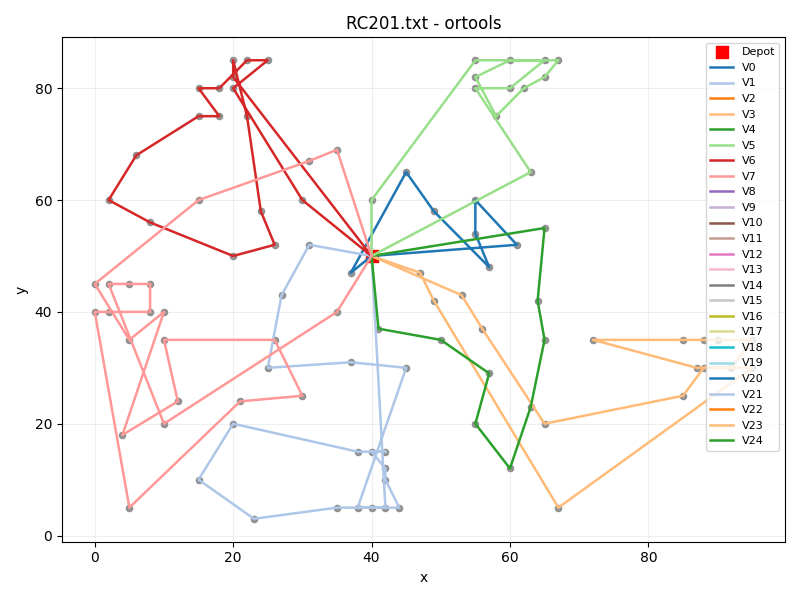

In [16]:
plot_routes(instance, dyn_sol)
plot_routes(instance, sol)

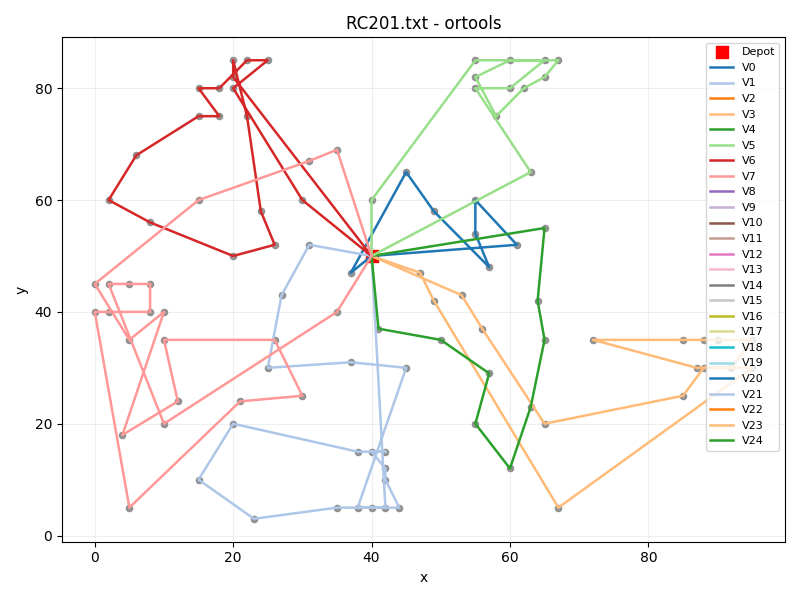

Saved dynamic route plot to ../outputs/notebook_heuristics/dynamic_route.png


In [8]:
if dyn_sol is not None:
    _ = plot_routes(scenario.instance, dyn_sol, out / 'dynamic_route.png')
    print('Saved dynamic route plot to', out / 'dynamic_route.png')
else:
    print('Scenario discarded as infeasible during dynamic transformation')

In [ ]:
inspect_dynamic(instance, sim, ORToolsVRPTWSolver().solve, budget_s=2, epsilon=0.1, seed=1, cutoff_ratio=0.1)

Dynamic scenario with 10 dynamic customers (epsilon=0.10), cutoff at 96.0s (10.00% of horizon)
Dynamic customer IDs: [4, 14, 25, 32, 44, 48, 71, 80, 90, 93]
